In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [6]:
# Parse iShares CSPX NAV data from official iShares XLS file
import re

# Read the file
with open("iShares-Core-SP-500-UCITS-ETF-USD-Acc_fund.xls", "r", encoding="utf-8-sig") as f:
    content = f.read()

# Extract Historique worksheet
hist_match = re.search(r'ss:Name=\"Historique\".*?</ss:Worksheet>', content, re.DOTALL)
hist_content = hist_match.group(0)

# Extract rows — date and VL (NAV)
rows = re.findall(
    r'<ss:Data ss:Type="String">(\d+/\w+\.?/\d+)</ss:Data>.*?'
    r'<ss:Data ss:Type="Number">([\d.]+)</ss:Data>',
    hist_content, re.DOTALL
)

# French month mapping
fr_months = {
    "janv.": "Jan", "févr.": "Feb", "mars": "Mar", "avr.": "Apr",
    "mai": "May", "juin": "Jun", "juil.": "Jul", "août": "Aug",
    "sept.": "Sep", "oct.": "Oct", "nov.": "Nov", "déc.": "Dec"
}

def parse_fr_date(date_str):
    for fr, en in fr_months.items():
        date_str = date_str.replace(fr, en)
    return pd.to_datetime(date_str, format="%d/%b/%Y", dayfirst=True)

# Build DataFrame
nav_df = pd.DataFrame(rows, columns=["date", "NAV"])
nav_df["date"] = nav_df["date"].apply(parse_fr_date)
nav_df["NAV"]  = nav_df["NAV"].astype(float)
nav_df = nav_df.set_index("date").sort_index()

# Filter 2020-2024
nav_df = nav_df.loc["2020-01-01":"2024-12-31"]

print(f"NAV data loaded: {len(nav_df)} days")
print(f"Period: {nav_df.index[0].date()} → {nav_df.index[-1].date()}")
print(f"\nSample:")
print(nav_df.head(5))

NAV data loaded: 1265 days
Period: 2020-01-02 → 2024-12-31

Sample:
                   NAV
date                  
2020-01-02  323.879600
2020-01-03  321.622181
2020-01-06  322.757435
2020-01-07  321.879533
2020-01-08  323.467969


In [7]:
# Download CSPX.L market price
raw = yf.download("CSPX.L", start="2020-01-01", end="2024-12-31", progress=False)
market_price = raw["Close"].squeeze()

# Align NAV and market price on common trading days
df = pd.DataFrame({
    "market_price": market_price,
    "NAV":          nav_df["NAV"]
}).dropna()

print(f"Common trading days: {len(df)}")
print(f"Period: {df.index[0].date()} → {df.index[-1].date()}")

# Premium/Discount in basis points
df["prem_disc_bps"] = (df["market_price"] - df["NAV"]) / df["NAV"] * 10000

print(f"\nPremium/Discount summary (bps):")
print(f"  Mean:              {df['prem_disc_bps'].mean():.2f} bps")
print(f"  Std:               {df['prem_disc_bps'].std():.2f} bps")
print(f"  Min:               {df['prem_disc_bps'].min():.2f} bps")
print(f"  Max:               {df['prem_disc_bps'].max():.2f} bps")
print(f"  % days at premium: {(df['prem_disc_bps'] > 0).mean():.1%}")
print(f"  % days at discount:{(df['prem_disc_bps'] < 0).mean():.1%}")

Common trading days: 1261
Period: 2020-01-02 → 2024-12-30

Premium/Discount summary (bps):
  Mean:              1.85 bps
  Std:               73.27 bps
  Min:               -662.09 bps
  Max:               550.12 bps
  % days at premium: 48.1%
  % days at discount:51.9%


In [8]:
# Identify stress events
threshold = 100  # 100 bps

stress_days = df[abs(df["prem_disc_bps"]) > threshold].copy()
stress_days["type"] = np.where(stress_days["prem_disc_bps"] > 0, "Premium", "Discount")

print(f"Days with |premium/discount| > {threshold} bps: {len(stress_days)}")
print(f"  Premium  > +{threshold} bps: {(stress_days['type']=='Premium').sum()} days")
print(f"  Discount < -{threshold} bps: {(stress_days['type']=='Discount').sum()} days")

print(f"\nTop 10 largest dislocations:")
print(f"{'Date':<14} {'P/D (bps)':>10} {'Type':<10}")
print("-" * 36)
top10 = df["prem_disc_bps"].abs().nlargest(10)
for date, val in top10.items():
    pd_val = df.loc[date, "prem_disc_bps"]
    ptype  = "Premium" if pd_val > 0 else "Discount"
    print(f"{str(date.date()):<14} {pd_val:>10.2f} {ptype:<10}")

Days with |premium/discount| > 100 bps: 145
  Premium  > +100 bps: 93 days
  Discount < -100 bps: 52 days

Top 10 largest dislocations:
Date            P/D (bps) Type      
------------------------------------
2020-03-13        -662.09 Discount  
2020-03-16         550.12 Premium   
2020-03-10        -434.56 Discount  
2022-05-04        -342.77 Discount  
2024-12-18         325.40 Premium   
2020-03-20         314.43 Premium   
2022-11-30        -301.94 Discount  
2021-12-01         301.44 Premium   
2022-01-24        -276.73 Discount  
2021-03-05        -266.42 Discount  


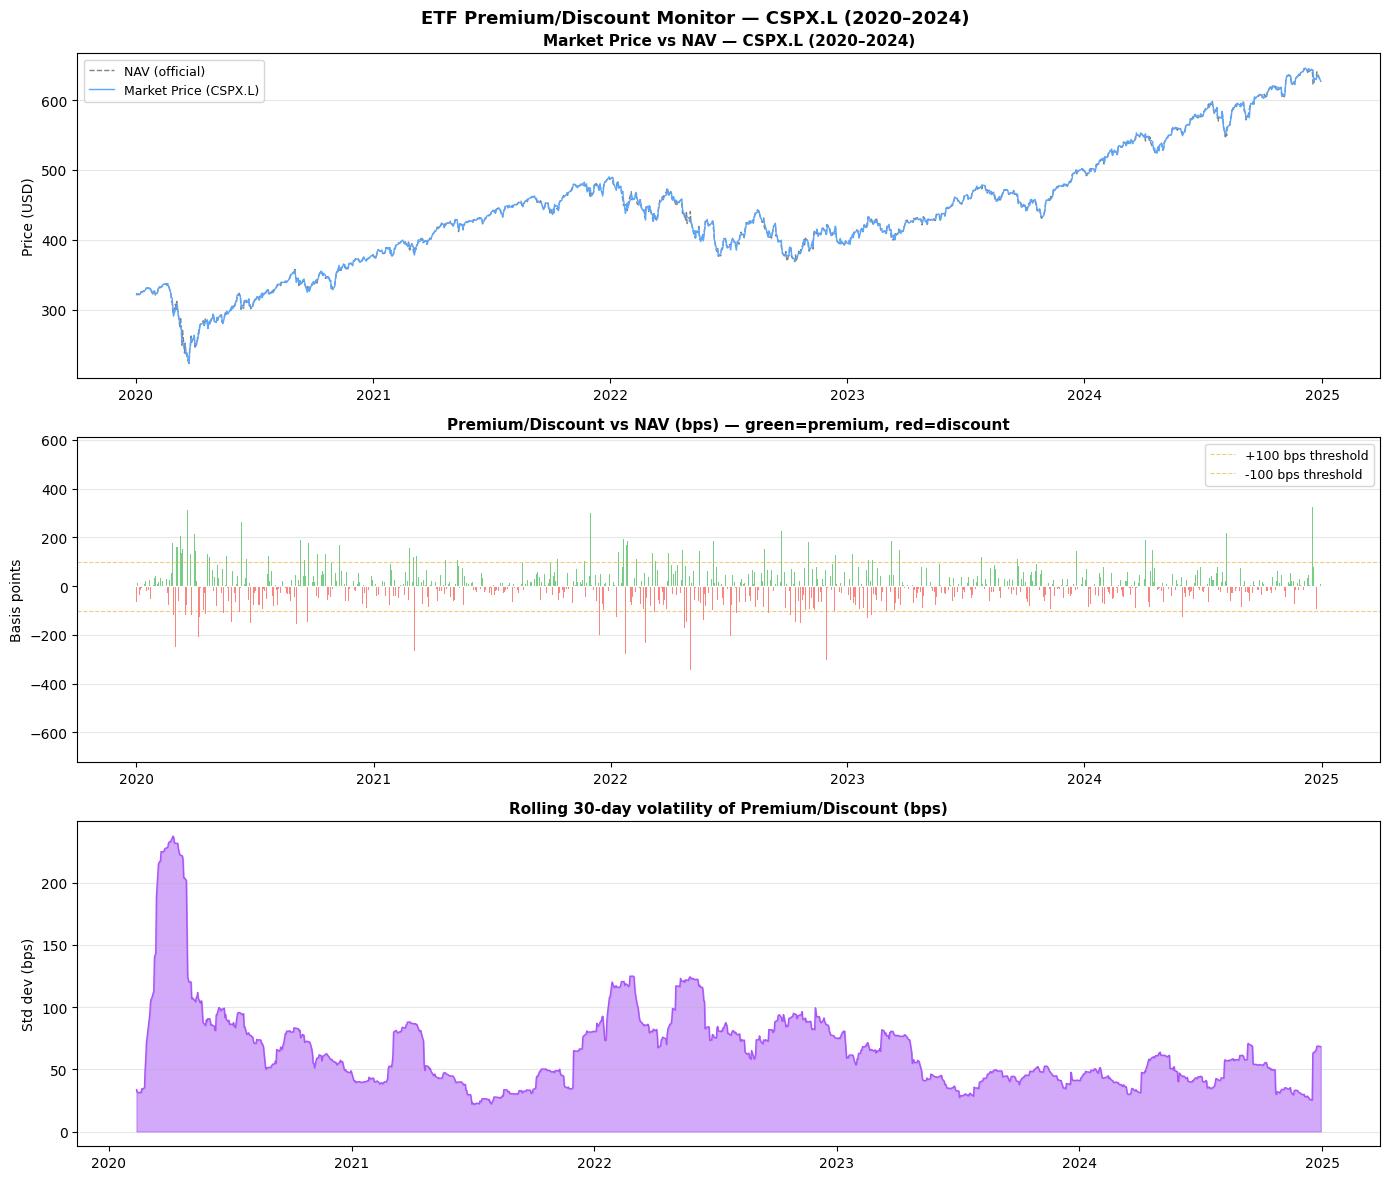

Chart saved.


In [9]:
# Premium/Discount chart
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ── Chart 1: Market price vs NAV ──
ax1 = axes[0]
ax1.plot(df.index, df["NAV"],
         color="gray", linewidth=1, linestyle="--", label="NAV (official)")
ax1.plot(df.index, df["market_price"],
         color="#58a6ff", linewidth=1, label="Market Price (CSPX.L)")
ax1.set_title("Market Price vs NAV — CSPX.L (2020–2024)",
              fontweight="bold", fontsize=11)
ax1.set_ylabel("Price (USD)")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# ── Chart 2: Premium/Discount over time ──
ax2 = axes[1]
colors = np.where(df["prem_disc_bps"] >= 0, "#3fb950", "#f85149")
ax2.bar(df.index, df["prem_disc_bps"],
        color=colors, width=1, alpha=0.7)
ax2.axhline(0, color="white", linewidth=0.8)
ax2.axhline(100,  color="#f5a623", linewidth=0.8,
            linestyle="--", alpha=0.6, label="+100 bps threshold")
ax2.axhline(-100, color="#f5a623", linewidth=0.8,
            linestyle="--", alpha=0.6, label="-100 bps threshold")
ax2.set_title("Premium/Discount vs NAV (bps) — green=premium, red=discount",
              fontweight="bold", fontsize=11)
ax2.set_ylabel("Basis points")
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.3)

# ── Chart 3: Rolling 30-day std of premium/discount ──
ax3 = axes[2]
rolling_std = df["prem_disc_bps"].rolling(30).std()
ax3.fill_between(rolling_std.index, rolling_std,
                  color="#a855f7", alpha=0.5)
ax3.plot(rolling_std.index, rolling_std,
         color="#a855f7", linewidth=1)
ax3.set_title("Rolling 30-day volatility of Premium/Discount (bps)",
              fontweight="bold", fontsize=11)
ax3.set_ylabel("Std dev (bps)")
ax3.grid(axis="y", alpha=0.3)

fig.suptitle("ETF Premium/Discount Monitor — CSPX.L (2020–2024)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/premium_discount.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

## Key Findings

### Normal market conditions
- Average premium/discount: **+1.85 bps** — near zero, confirming efficient
  arbitrage by market makers keeps CSPX.L trading very close to its NAV
- 48% premium / 52% discount days — well balanced, sign of a liquid ETF

### Stress events
- **March 2020 (Covid crash)**: largest dislocations (-662 bps / +550 bps in 3 days)
  Market makers widened spreads dramatically as hedging costs spiked and
  S&P 500 futures liquidity deteriorated
- **May 2022 / Nov 2022**: Fed hawkish pivots caused intraday dislocations
  as European markets repriced before the US session opened
- **Dec 2024**: Fed "higher for longer" surprise — US market continued
  selling off after London close, creating apparent premium at London close

### Closing price risk
All large dislocations share the same root cause: the **3.5-hour gap**
between London close (17:30 UK) and NYSE close (21:00 UK).
European market makers must hedge residual exposure via S&P 500 futures (ES1)
after London closes — during stress, this hedge becomes expensive or unavailable,
causing temporary dislocations.

### Practical implication
A market maker seeing a +300 bps premium at London close cannot immediately
arb it away — the underlying basket is still trading in the US.
The AP (Authorised Participant) mechanism corrects dislocations at end of day
via creation/redemption, which is why the mean reverts to near zero over time.